# 🛒 Shopper Spectrum: Customer Segmentation and Product Recommendations in E-Commerce

**Goal:** Segment customers using RFM + KMeans clustering, and build an item-based collaborative filtering product recommendation system.

---
## Step 1: Dataset Collection and Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('online_retail.csv', encoding='latin1')
print("Shape:", df.shape)
df.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


### Dataset Description

| Column | Description |
|---|---|
| InvoiceNo | Transaction number |
| StockCode | Unique product/item code |
| Description | Name of the product |
| Quantity | Number of products purchased |
| InvoiceDate | Date and time of transaction |
| UnitPrice | Price per product |
| CustomerID | Unique identifier for each customer |
| Country | Country where the customer is based |

### Checking for missing values, duplicates, and unusual records

In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nCancelled invoices (InvoiceNo starting with 'C'):", df[df['InvoiceNo'].astype(str).str.startswith('C')].shape[0])
print("\nNegative Quantity:", (df['Quantity'] < 0).sum())
print("Negative/Zero UnitPrice:", (df['UnitPrice'] <= 0).sum())
print("\nUnique Customers:", df['CustomerID'].nunique())
print("Unique Products (StockCode):", df['StockCode'].nunique())
print("Unique Countries:", df['Country'].nunique())
print("\nDate range:", df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

Missing values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64



Duplicate rows: 5268

Cancelled invoices (InvoiceNo starting with 'C'): 9288

Negative Quantity: 10624
Negative/Zero UnitPrice: 2517

Unique Customers: 4372
Unique Products (StockCode): 4070
Unique Countries: 38



Date range: 2022-12-01 08:26:00 to 2023-12-09 12:50:00


---
## Step 2: Data Preprocessing

- Remove rows with missing `CustomerID`
- Exclude cancelled invoices (`InvoiceNo` starting with 'C')
- Remove negative or zero `Quantity` and `UnitPrice`
- Remove duplicate rows

In [5]:
df_clean = df.copy()
print("Original shape:", df_clean.shape)

# Remove missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])
print("After removing missing CustomerID:", df_clean.shape)

# Remove cancelled invoices
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print("After removing cancelled invoices:", df_clean.shape)

# Remove negative/zero quantity
df_clean = df_clean[df_clean['Quantity'] > 0]
print("After removing negative/zero quantity:", df_clean.shape)

# Remove negative/zero price
df_clean = df_clean[df_clean['UnitPrice'] > 0]
print("After removing negative/zero price:", df_clean.shape)

# Remove duplicates
df_clean = df_clean.drop_duplicates()
print("After removing duplicates:", df_clean.shape)

# Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

# Convert CustomerID to int (was float due to NaNs originally)
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

print("\nFinal missing values:\n", df_clean.isnull().sum())

Original shape: (541909, 8)
After removing missing CustomerID: (406829, 8)
After removing cancelled invoices: (397924, 8)
After removing negative/zero quantity: (397924, 8)


After removing negative/zero price: (397884, 8)


After removing duplicates: (392692, 8)

Final missing values:
 InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [6]:
# Add a TotalPrice column - will be useful for Monetary calculation later
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print("Unique customers:", df_clean['CustomerID'].nunique())
print("Unique products:", df_clean['StockCode'].nunique())
df_clean.head()

Unique customers: 4338
Unique products: 3665


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


---
## Step 3: Exploratory Data Analysis (EDA)

### 3.1 Transaction Volume by Country

/tmp/ipykernel_978/2245686409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')


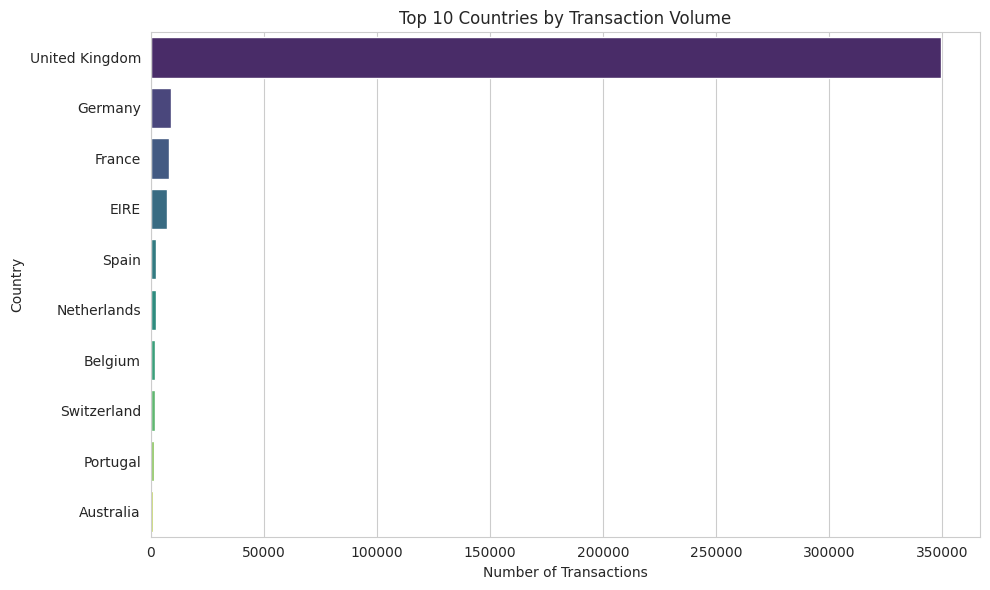

Country
United Kingdom    349203
Germany             9025
France              8326
EIRE                7226
Spain               2479
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1453
Australia           1181
Name: count, dtype: int64


In [7]:
country_counts = df_clean['Country'].value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='viridis')
plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

print(country_counts)

### 3.2 Top-Selling Products

/tmp/ipykernel_978/605072734.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='magma')


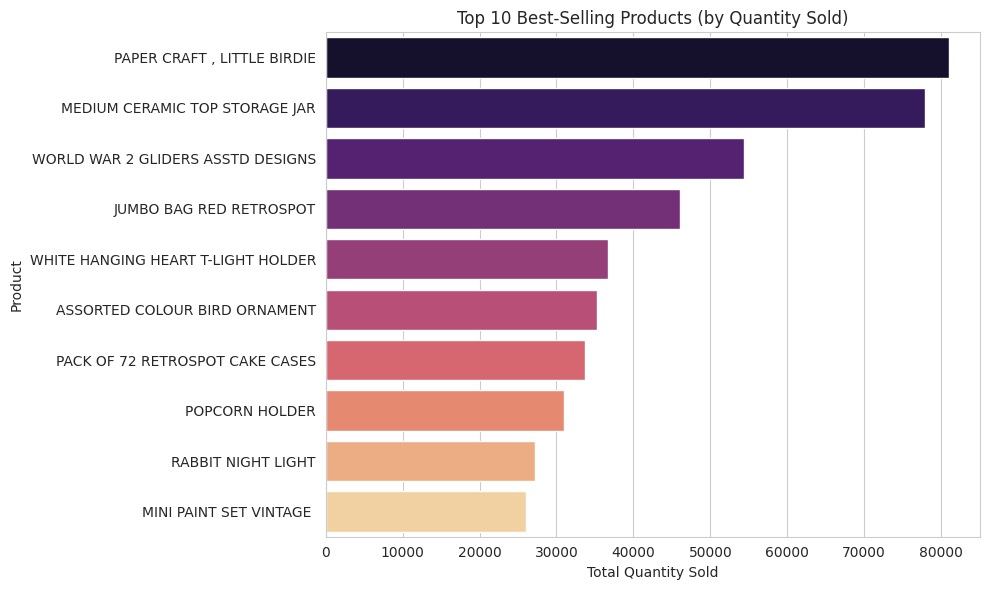

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


In [8]:
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Best-Selling Products (by Quantity Sold)')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

print(top_products)

### 3.3 Purchase Trends Over Time

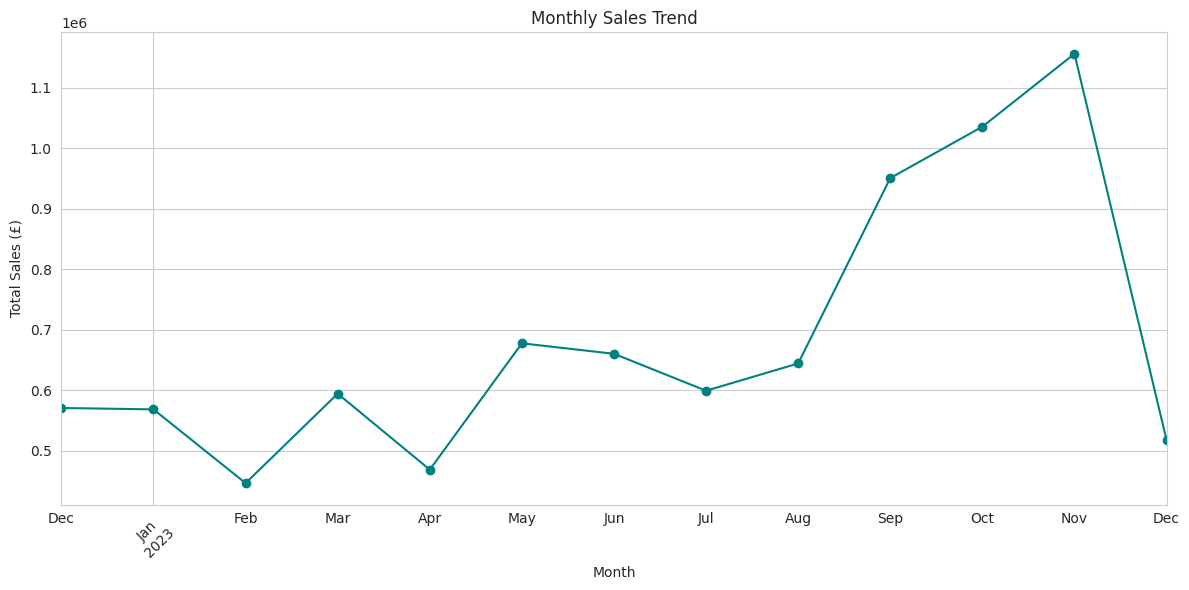

In [9]:
df_clean['InvoiceMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_sales = df_clean.groupby('InvoiceMonth')['TotalPrice'].sum()

plt.figure(figsize=(12,6))
monthly_sales.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

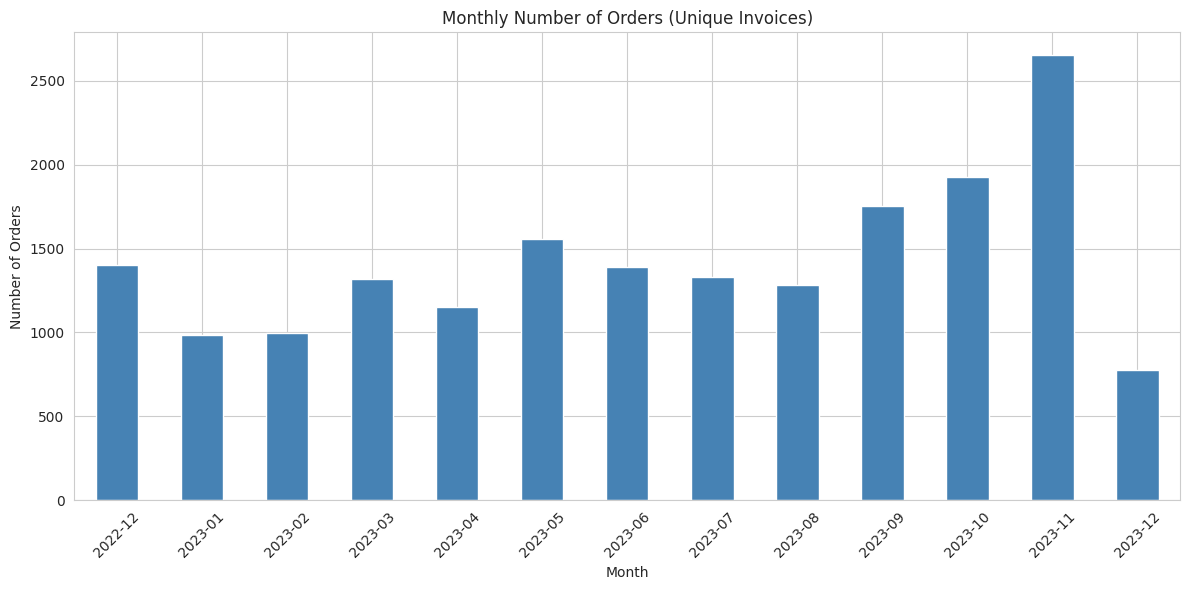

In [10]:
monthly_orders = df_clean.groupby('InvoiceMonth')['InvoiceNo'].nunique()

plt.figure(figsize=(12,6))
monthly_orders.plot(kind='bar', color='steelblue')
plt.title('Monthly Number of Orders (Unique Invoices)')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.4 Monetary Distribution - Per Transaction

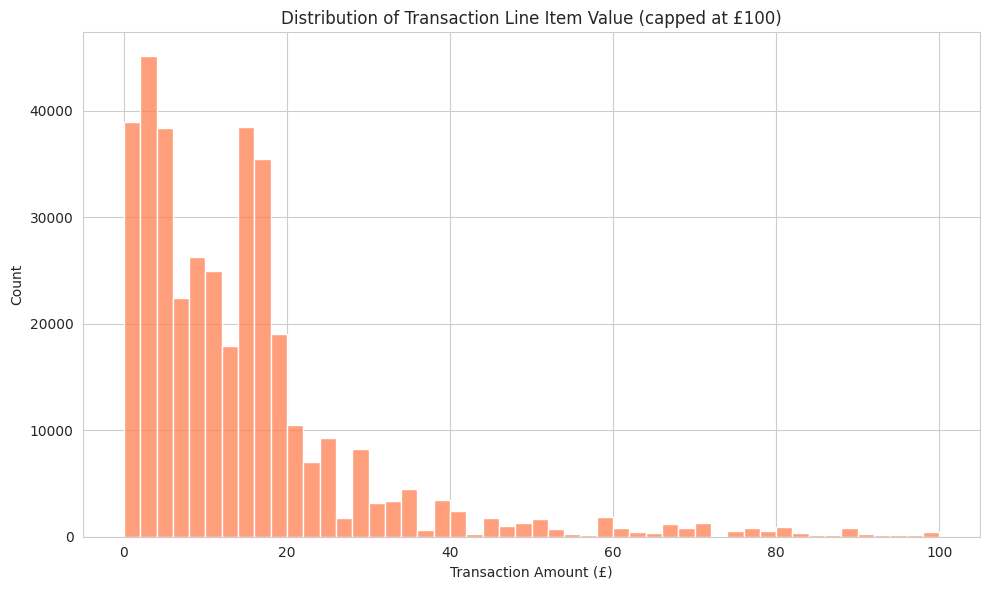

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64


In [11]:
plt.figure(figsize=(10,6))
transaction_filtered = df_clean[df_clean['TotalPrice'] <= 100]['TotalPrice']
sns.histplot(transaction_filtered, bins=50, kde=False, color='coral', edgecolor='white')
plt.title('Distribution of Transaction Line Item Value (capped at £100)')
plt.xlabel('Transaction Amount (£)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(df_clean['TotalPrice'].describe())

### 3.5 Monetary Distribution - Per Customer

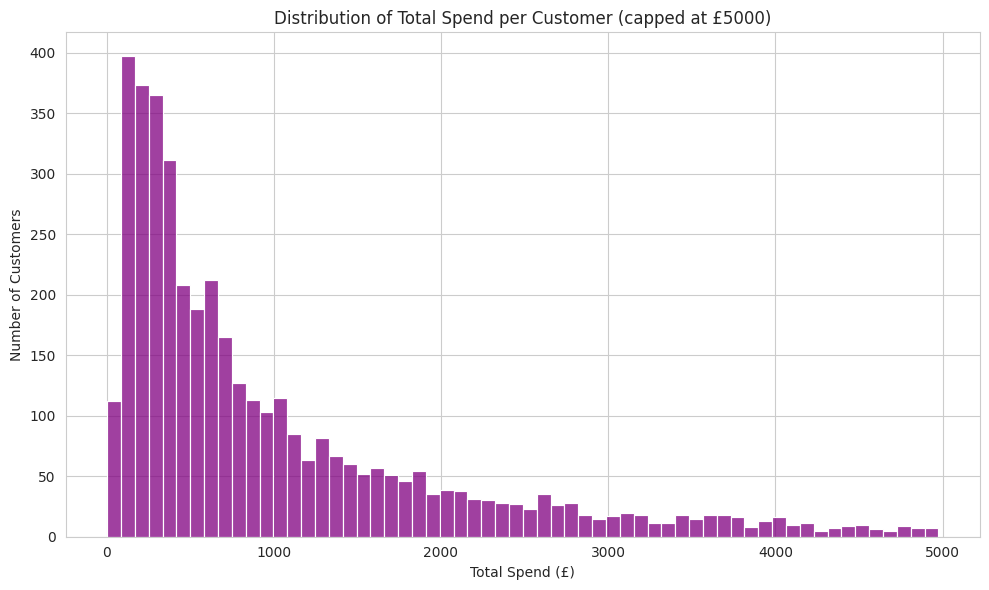

count      4338.000000
mean       2048.688081
std        8985.230220
min           3.750000
25%         306.482500
50%         668.570000
75%        1660.597500
max      280206.020000
Name: TotalPrice, dtype: float64


In [12]:
customer_spend = df_clean.groupby('CustomerID')['TotalPrice'].sum()

plt.figure(figsize=(10,6))
sns.histplot(customer_spend[customer_spend <= 5000], bins=60, kde=False, color='purple', edgecolor='white')
plt.title('Distribution of Total Spend per Customer (capped at £5000)')
plt.xlabel('Total Spend (£)')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

print(customer_spend.describe())

---
## Step 4: RFM Feature Engineering & Clustering

### 4.1 Calculate RFM Metrics

- **Recency** = days since customer's last purchase (relative to the most recent date in the dataset)
- **Frequency** = number of distinct transactions (invoices) per customer
- **Monetary** = total amount spent by customer

In [13]:
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Snapshot date (reference point for Recency):", snapshot_date)

rfm = df_clean.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print("\nRFM table shape:", rfm.shape)
rfm.head()

Snapshot date (reference point for Recency): 2023-12-10 12:50:00



RFM table shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [14]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.688081
std,1721.808492,100.014169,7.697998,8985.230220
min,12346.000000,1.000000,1.000000,3.750000
25%,13813.250000,18.000000,1.000000,306.482500
50%,15299.500000,51.000000,2.000000,668.570000
75%,16778.750000,142.000000,5.000000,1660.597500
max,18287.000000,374.000000,209.000000,280206.020000


### 4.2 RFM Distributions (before scaling)

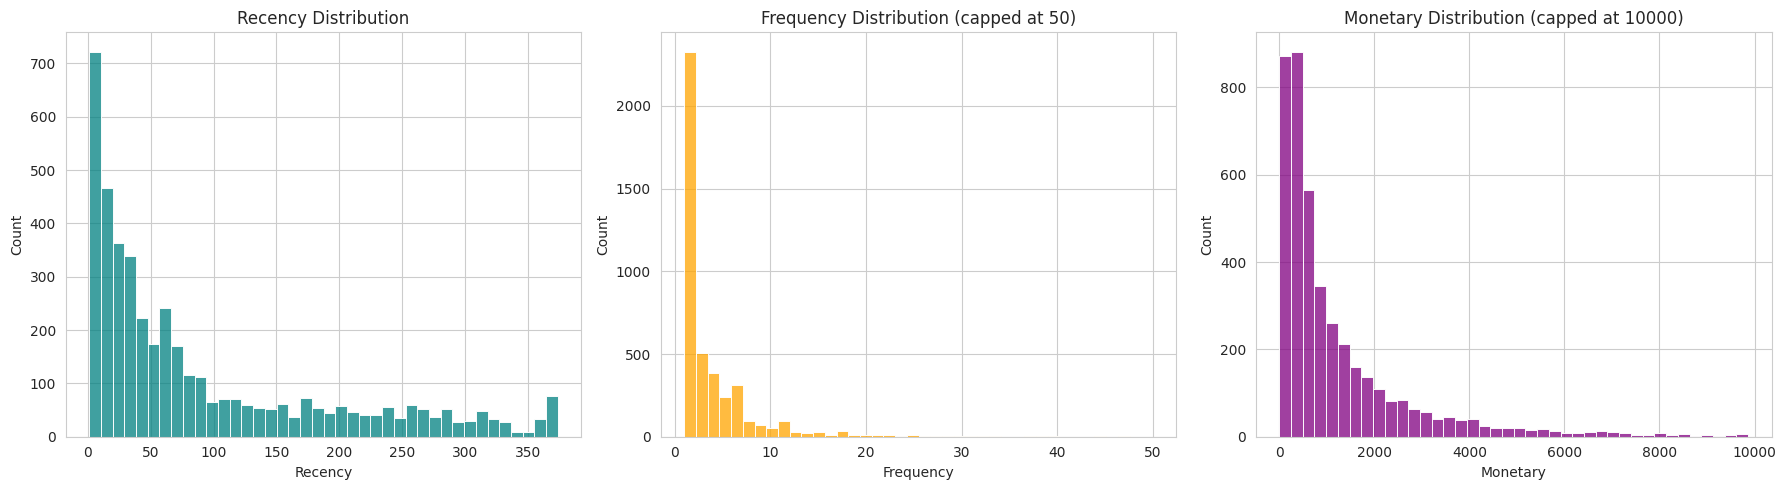

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm['Recency'], bins=40, color='teal', ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm[rfm['Frequency'] <= 50]['Frequency'], bins=40, color='orange', ax=axes[1])
axes[1].set_title('Frequency Distribution (capped at 50)')

sns.histplot(rfm[rfm['Monetary'] <= 10000]['Monetary'], bins=40, color='purple', ax=axes[2])
axes[2].set_title('Monetary Distribution (capped at 10000)')

plt.tight_layout()
plt.show()

### 4.3 Standardize RFM Values

RFM values are on very different scales (and right-skewed), so we apply a log transform to reduce skew, then standardize with `StandardScaler` before clustering.

In [16]:
from sklearn.preprocessing import StandardScaler

# Log transform to reduce skewness (add 1 to avoid log(0))
rfm_log = rfm[['Recency', 'Frequency', 'Monetary']].apply(lambda x: np.log1p(x))

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

rfm_scaled.head()

,Recency,Frequency,Monetary
0,1.461993,-0.955214,3.707716
1,-2.038734,1.074425,1.414903
2,0.373104,0.386304,0.720024
3,-0.623086,-0.955214,0.702287
4,1.424558,-0.955214,-0.614514


### 4.4 Elbow Method & Silhouette Score to Choose Number of Clusters

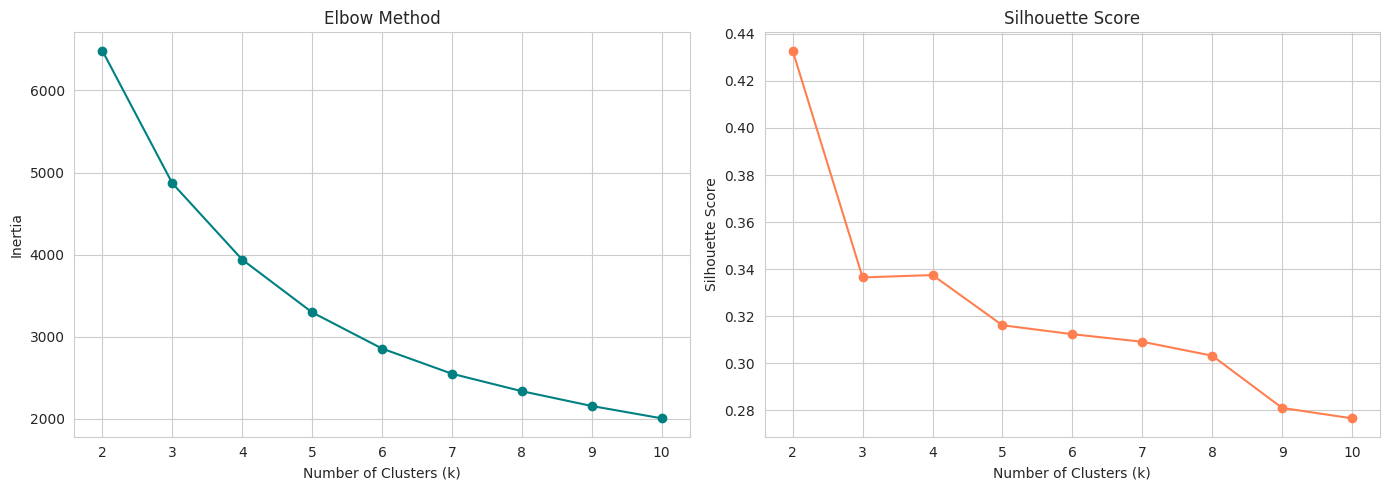

k=2: silhouette=0.4328
k=3: silhouette=0.3365
k=4: silhouette=0.3375
k=5: silhouette=0.3162
k=6: silhouette=0.3124
k=7: silhouette=0.3092
k=8: silhouette=0.3033
k=9: silhouette=0.2811
k=10: silhouette=0.2767


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(rfm_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(K_range, inertia, marker='o', color='teal')
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sil_scores, marker='o', color='coral')
axes[1].set_title('Silhouette Score')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

for k, s in zip(K_range, sil_scores):
    print(f"k={k}: silhouette={s:.4f}")

### 4.5 Run KMeans with k=4

Based on the Elbow method and Silhouette analysis, **k=4** gives a good balance — the elbow curve flattens around here, and the project requires exactly 4 business-meaningful segments: **High-Value, Regular, Occasional, At-Risk**.

In [18]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("Silhouette Score (k=4):", silhouette_score(rfm_scaled, rfm['Cluster']))
print("\nCluster sizes:\n", rfm['Cluster'].value_counts().sort_index())

Silhouette Score (k=4): 0.33751704921261194

Cluster sizes:
 Cluster
0     713
1    1622
2     837
3    1166
Name: count, dtype: int64


### 4.6 Interpret Clusters using RFM Averages

In [19]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().round(1)
cluster_profile['Count'] = rfm['Cluster'].value_counts().sort_index()
cluster_profile

,Recency,Frequency,Monetary,Count
Cluster,,,,
0,12.2,13.8,8088.0,713
1,181.5,1.3,341.0,1622
2,17.7,2.2,557.3,837
3,71.6,4.1,1801.8,1166


In [20]:
# Label clusters based on their RFM averages:
# - Low Recency + High Frequency + High Monetary -> High-Value
# - Moderate values across the board -> Regular
# - Low Frequency + Low Monetary -> Occasional
# - High Recency (haven't purchased in a while) -> At-Risk

# Rank clusters: lower Recency is better, higher Frequency/Monetary is better
cluster_profile['R_rank'] = cluster_profile['Recency'].rank(ascending=True)   # low recency = best = rank 1
cluster_profile['F_rank'] = cluster_profile['Frequency'].rank(ascending=False) # high frequency = best = rank 1
cluster_profile['M_rank'] = cluster_profile['Monetary'].rank(ascending=False)  # high monetary = best = rank 1
cluster_profile['Score'] = cluster_profile['R_rank'] + cluster_profile['F_rank'] + cluster_profile['M_rank']

cluster_profile_sorted = cluster_profile.sort_values('Score')
print(cluster_profile_sorted)

# Assign labels based on overall score ranking
labels_ordered = ['High-Value', 'Regular', 'Occasional', 'At-Risk']
score_to_label = dict(zip(cluster_profile_sorted.index, labels_ordered))
print("\nCluster -> Label mapping:", score_to_label)

rfm['Segment'] = rfm['Cluster'].map(score_to_label)
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)

         Recency  Frequency  Monetary  Count  R_rank  F_rank  M_rank  Score
Cluster                                                                    
0           12.2       13.8    8088.0    713     1.0     1.0     1.0    3.0
3           71.6        4.1    1801.8   1166     3.0     2.0     2.0    7.0
2           17.7        2.2     557.3    837     2.0     3.0     3.0    8.0
1          181.5        1.3     341.0   1622     4.0     4.0     4.0   12.0

Cluster -> Label mapping: {0: 'High-Value', 3: 'Regular', 2: 'Occasional', 1: 'At-Risk'}


,Recency,Frequency,Monetary
Segment,,,
At-Risk,181.5,1.3,341.0
High-Value,12.2,13.8,8088.0
Occasional,17.7,2.2,557.3
Regular,71.6,4.1,1801.8


In [21]:
rfm['Segment'].value_counts()

Segment
At-Risk       1622
Regular       1166
Occasional     837
High-Value     713
Name: count, dtype: int64

### 4.7 Visualize Clusters

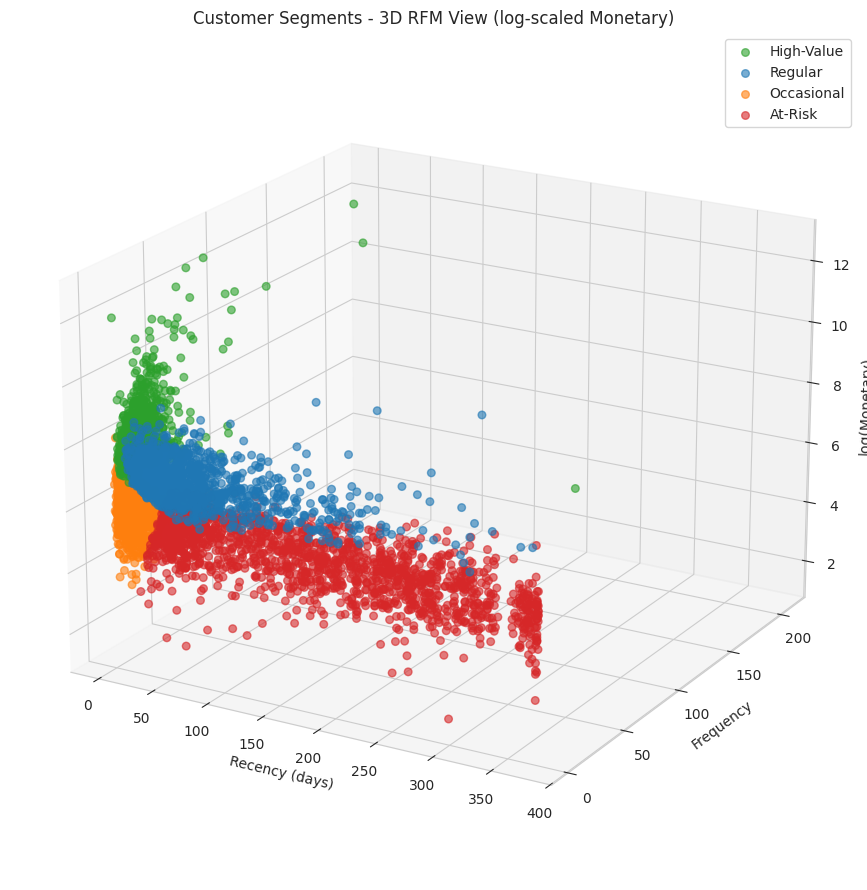

In [22]:
from mpl_toolkits.mplot3d import Axes3D

segment_colors = {'High-Value': '#2ca02c', 'Regular': '#1f77b4', 'Occasional': '#ff7f0e', 'At-Risk': '#d62728'}

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Use log scale for Monetary so extreme outliers don't squash the rest of the points
for seg, color in segment_colors.items():
    subset = rfm[rfm['Segment'] == seg]
    ax.scatter(subset['Recency'], subset['Frequency'], np.log1p(subset['Monetary']),
               label=seg, color=color, alpha=0.6, s=30)

ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency')
ax.set_zlabel('log(Monetary)')
ax.set_title('Customer Segments - 3D RFM View (log-scaled Monetary)')
ax.legend()
ax.view_init(elev=20, azim=-60)
plt.tight_layout()
plt.show()

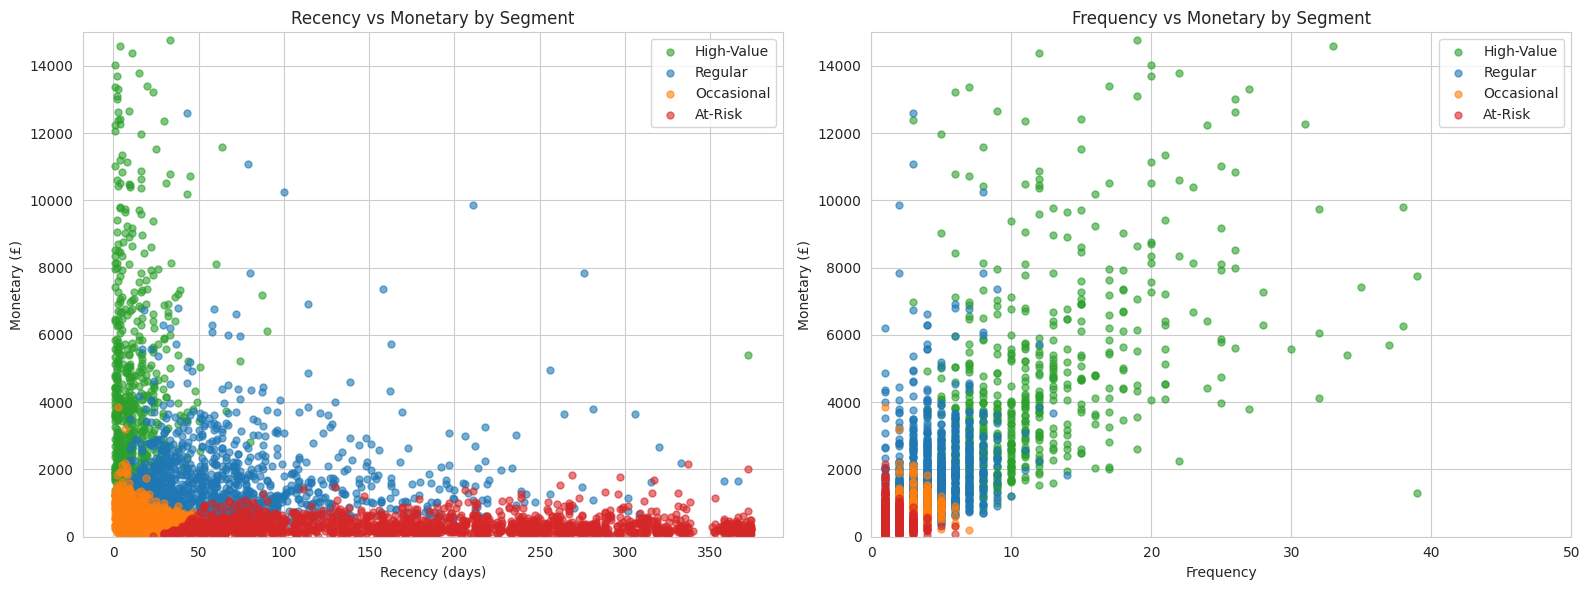

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

for seg, color in segment_colors.items():
    subset = rfm[rfm['Segment'] == seg]
    axes[0].scatter(subset['Recency'], subset['Monetary'], label=seg, color=color, alpha=0.6, s=25)
axes[0].set_xlabel('Recency (days)')
axes[0].set_ylabel('Monetary (£)')
axes[0].set_title('Recency vs Monetary by Segment')
axes[0].legend()
axes[0].set_ylim(0, 15000)

for seg, color in segment_colors.items():
    subset = rfm[rfm['Segment'] == seg]
    axes[1].scatter(subset['Frequency'], subset['Monetary'], label=seg, color=color, alpha=0.6, s=25)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Monetary (£)')
axes[1].set_title('Frequency vs Monetary by Segment')
axes[1].legend()
axes[1].set_xlim(0, 50)
axes[1].set_ylim(0, 15000)

plt.tight_layout()
plt.show()

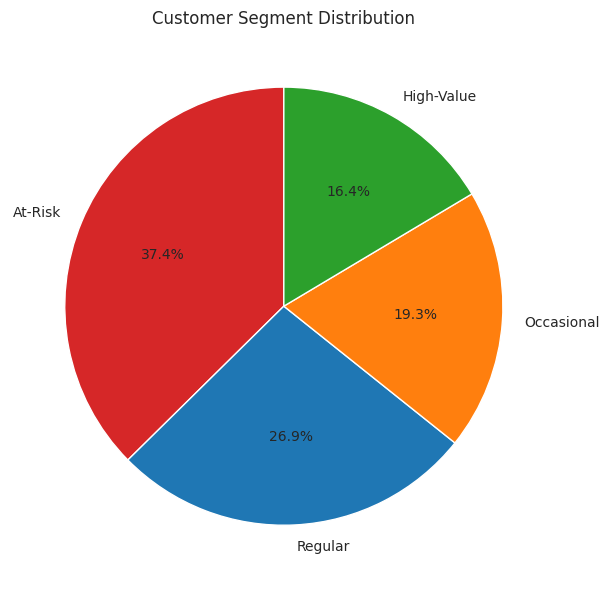

Segment
At-Risk       1622
Regular       1166
Occasional     837
High-Value     713
Name: count, dtype: int64


In [24]:
plt.figure(figsize=(8,6))
segment_counts = rfm['Segment'].value_counts()
colors_ordered = [segment_colors[s] for s in segment_counts.index]
plt.pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%', colors=colors_ordered, startangle=90)
plt.title('Customer Segment Distribution')
plt.tight_layout()
plt.show()
print(segment_counts)

---
## Step 5: Save the Clustering Model

We save the trained KMeans model, the StandardScaler, and the cluster-to-segment label mapping. The Streamlit app will load these to predict a segment for a new customer's Recency, Frequency, and Monetary input.

In [25]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'rfm_scaler.pkl')
joblib.dump(score_to_label, 'cluster_label_map.pkl')

print("Saved: kmeans_model.pkl, rfm_scaler.pkl, cluster_label_map.pkl")

Saved: kmeans_model.pkl, rfm_scaler.pkl, cluster_label_map.pkl


---
## Step 6: Product Recommendation System (Item-Based Collaborative Filtering)

**Approach:**
1. Build a Customer–Product matrix (rows = CustomerID, columns = Product Description, values = total Quantity purchased)
2. Compute cosine similarity between products based on purchase patterns across customers
3. Given a product name, return the top 5 most similar products

In [26]:
# Use the Description as the product identifier (more human-readable than StockCode)
# Standardize description text (strip extra whitespace, uppercase - dataset is already mostly uppercase)
df_clean['Description'] = df_clean['Description'].str.strip()

print("Number of unique product descriptions:", df_clean['Description'].nunique())

# Build Customer-Product matrix: rows = CustomerID, columns = Description, values = total quantity purchased
customer_product = df_clean.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print("Customer-Product matrix shape:", customer_product.shape)

Number of unique product descriptions: 3866


Customer-Product matrix shape: (4338, 3866)


In [27]:
from sklearn.metrics.pairwise import cosine_similarity

# Transpose so rows = products, columns = customers -> compute product-product similarity
product_customer = customer_product.T

product_similarity = cosine_similarity(product_customer)
product_similarity_df = pd.DataFrame(product_similarity,
                                       index=product_customer.index,
                                       columns=product_customer.index)

print("Product similarity matrix shape:", product_similarity_df.shape)
product_similarity_df.iloc[:5, :5]

Product similarity matrix shape: (3866, 3866)


Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED
Description,,,,,
10 COLOUR SPACEBOY PEN,1.000000,0.030829,0.005989,0.001467,0.000000
12 COLOURED PARTY BALLOONS,0.030829,1.000000,0.049282,0.057428,0.007737
12 DAISY PEGS IN WOOD BOX,0.005989,0.049282,1.000000,0.490186,0.000000
12 EGG HOUSE PAINTED WOOD,0.001467,0.057428,0.490186,1.000000,0.000000
12 HANGING EGGS HAND PAINTED,0.000000,0.007737,0.000000,0.000000,1.000000


### 6.1 Recommendation Function

In [28]:
def get_similar_products(product_name, top_n=5):
    """Return top_n products most similar to the given product, based on item-based collaborative filtering."""
    if product_name not in product_similarity_df.index:
        return f"Product '{product_name}' not found in catalog."
    
    similar_scores = product_similarity_df[product_name].sort_values(ascending=False)
    similar_scores = similar_scores.drop(product_name)  # exclude itself
    top_products = similar_scores.head(top_n)
    return top_products

# Test the function
get_similar_products('WHITE HANGING HEART T-LIGHT HOLDER')

Description
GIN + TONIC DIET METAL SIGN         0.750192
RED HANGING HEART T-LIGHT HOLDER    0.658714
WASHROOM METAL SIGN                 0.643520
LAUNDRY 15C METAL SIGN              0.642200
GREEN VINTAGE SPOT BEAKER           0.631463
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64

In [29]:
# Test with another product mentioned in the project brief
get_similar_products('GREEN VINTAGE SPOT BEAKER')

Description
BLUE VINTAGE SPOT BEAKER          0.997666
PINK VINTAGE SPOT BEAKER          0.997622
POTTING SHED CANDLE CITRONELLA    0.995713
POTTING SHED ROSE CANDLE          0.995686
PANTRY CHOPPING BOARD             0.995108
Name: GREEN VINTAGE SPOT BEAKER, dtype: float64

### 6.2 Product Recommendation Heatmap (sample)

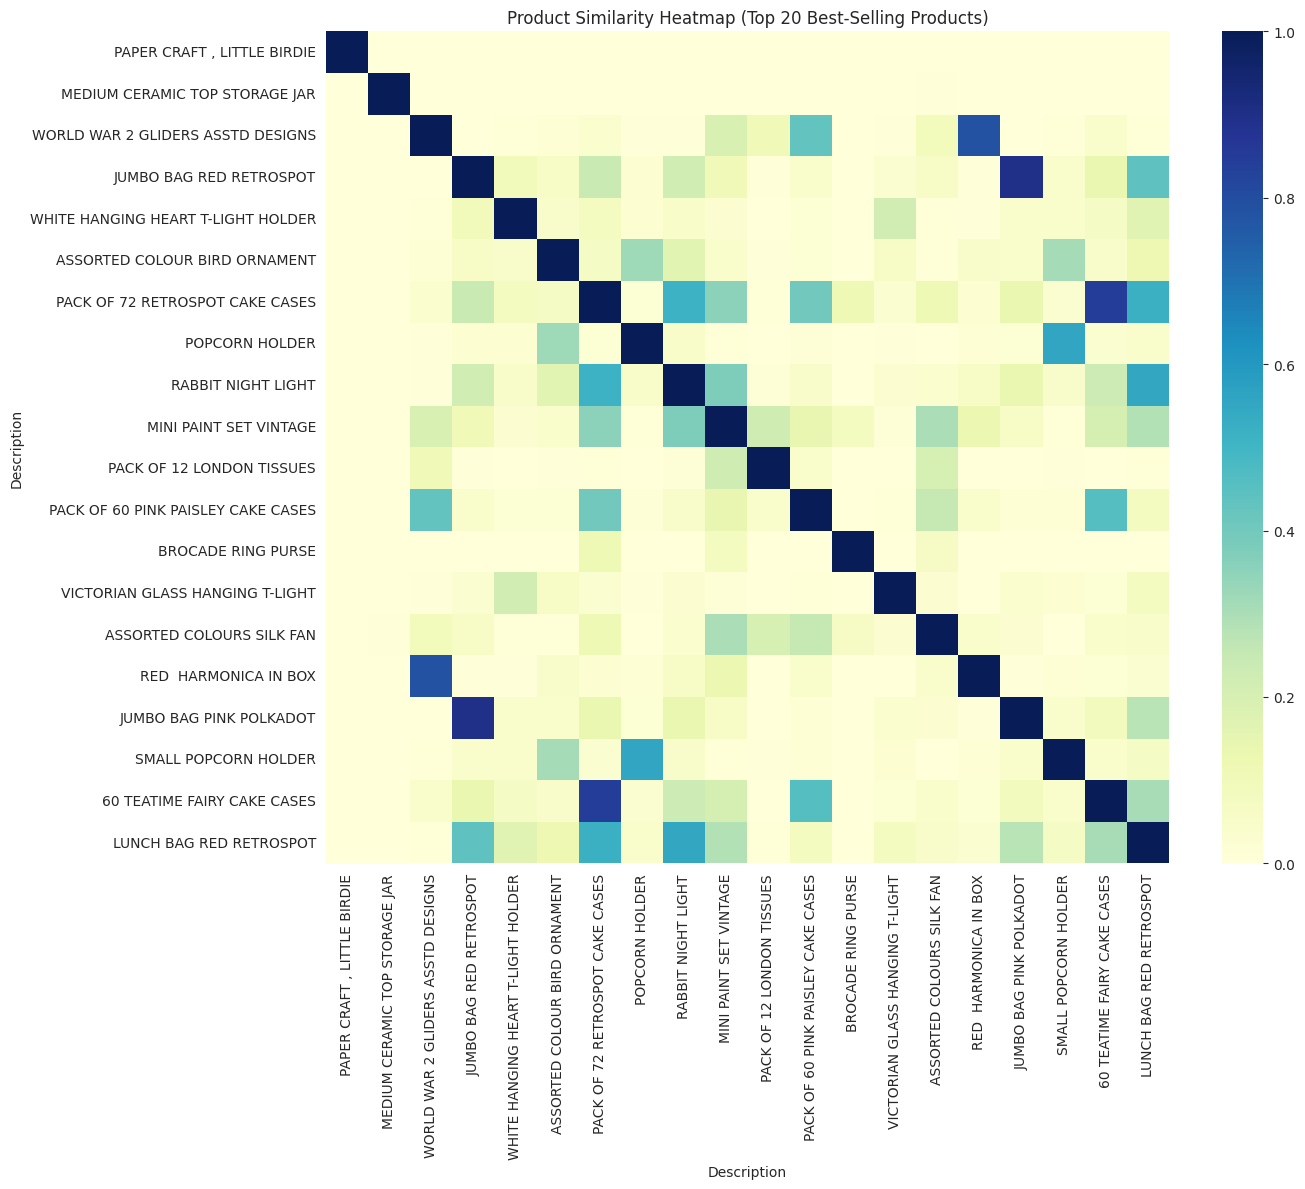

In [30]:
# Visualize similarity for a sample of top-selling products
top_20_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(20).index
sample_similarity = product_similarity_df.loc[top_20_products, top_20_products]

plt.figure(figsize=(14,12))
sns.heatmap(sample_similarity, cmap='YlGnBu', annot=False, xticklabels=True, yticklabels=True)
plt.title('Product Similarity Heatmap (Top 20 Best-Selling Products)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### 6.3 Save the Recommendation Artifacts

Save the product similarity matrix so the Streamlit app can load it directly without recomputing.

In [31]:
# Reduce file size: convert to float32 (instead of float64) - halves the size with no real accuracy loss
product_similarity_small = product_similarity_df.astype(np.float32)

joblib.dump(product_similarity_small, 'product_similarity.pkl', compress=3)

import os
size_mb = os.path.getsize('product_similarity.pkl') / (1024*1024)
print(f"product_similarity.pkl size: {size_mb:.2f} MB")

product_similarity.pkl size: 34.68 MB


---
## Model Evaluation Summary

In [32]:
print("=== Clustering Model Evaluation ===")
print(f"Algorithm: KMeans")
print(f"Number of clusters: 4")
print(f"Inertia (within-cluster sum of squares): {kmeans.inertia_:.2f}")
print(f"Silhouette Score: {silhouette_score(rfm_scaled, rfm['Cluster']):.4f}")
print()
print("Cluster Profile (RFM averages):")
print(rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1))
print()
print("Segment sizes:")
print(rfm['Segment'].value_counts())
print()
print("=== Recommendation System Evaluation ===")
print(f"Method: Item-based Collaborative Filtering (Cosine Similarity)")
print(f"Products in similarity matrix: {product_similarity_df.shape[0]}")
print(f"Customers used to build product profiles: {customer_product.shape[0]}")

=== Clustering Model Evaluation ===
Algorithm: KMeans
Number of clusters: 4
Inertia (within-cluster sum of squares): 3939.05


Silhouette Score: 0.3375

Cluster Profile (RFM averages):
            Recency  Frequency  Monetary
Segment                                 
At-Risk       181.5        1.3     341.0
High-Value     12.2       13.8    8088.0
Occasional     17.7        2.2     557.3
Regular        71.6        4.1    1801.8

Segment sizes:
Segment
At-Risk       1622
Regular       1166
Occasional     837
High-Value     713
Name: count, dtype: int64

=== Recommendation System Evaluation ===
Method: Item-based Collaborative Filtering (Cosine Similarity)
Products in similarity matrix: 3866
Customers used to build product profiles: 4338
